In [ ]:
import os

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerBase

In [2]:
# Create a directory to store the plots in
ora_comparison_plots_dir = "ORA_comparison_plots"

if not os.path.exists(ora_comparison_plots_dir):
    os.makedirs(ora_comparison_plots_dir)

In [3]:
# Load the long format comparison TSV file into a DataFrame
comparison_average_long_df = pd.read_csv(
    "ORA_comparison_average_-log10(Benjamini)_long_format_copy.tsv",
    sep="\t"
)

# Generation of Figures for Manuscript

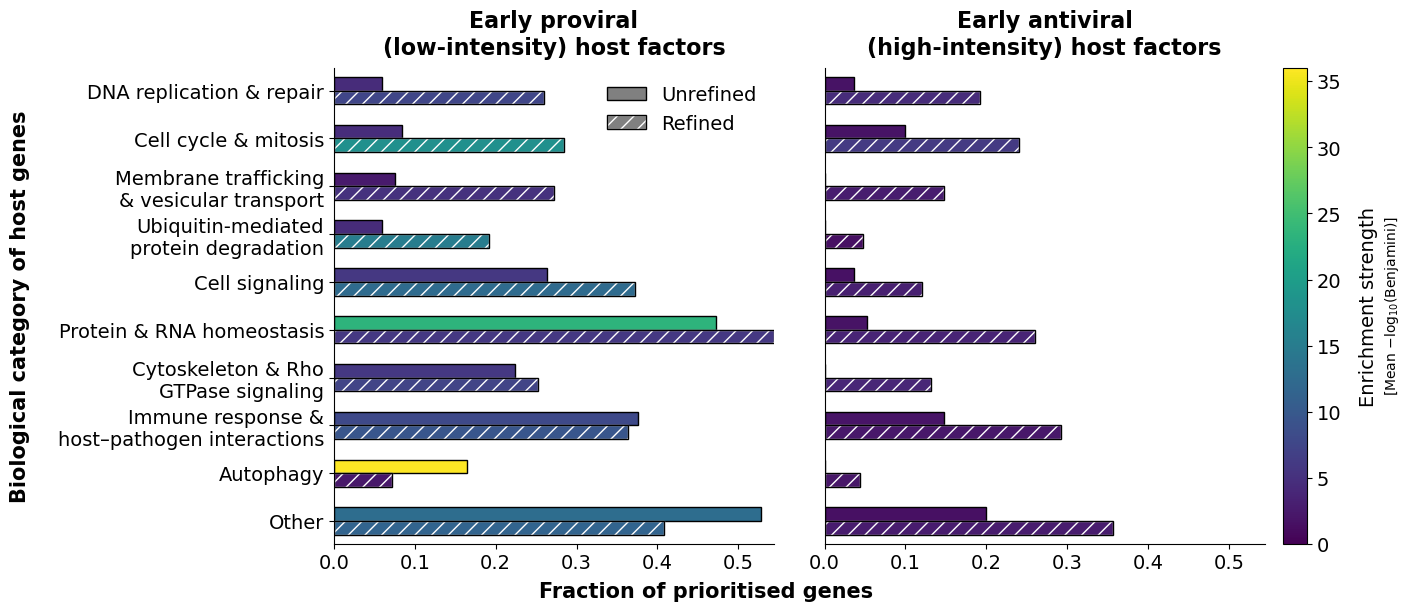

In [15]:
# Generate the figure for the main manuscript displaying early low
# (proviral) and early high (antiviral) intensities
# Only these two intensity regimes are shown as the trends are similar
# for late intensities

# ============================================================
# Select early-low and early-high data
#
# Early-low  = low-intensity proviral host factors
# Early-high = high-intensity antiviral host factors
# ============================================================

early_low_df = comparison_average_long_df[
    comparison_average_long_df["ORA"].isin(
        ["early_low_unrefined", "early_low_refined"]
    )
].copy()

early_high_df = comparison_average_long_df[
    comparison_average_long_df["ORA"].isin(
        ["early_high_unrefined", "early_high_refined"]
    )
].copy()


# ============================================================
# Sort categories by the difference in early-low intensities
#
# Difference = early_low_refined - early_low_unrefined
#
# Largest positive difference appears at the top.
# ============================================================

early_unrefined_sort = (
    early_low_df[
        early_low_df["ORA"] == "early_low_unrefined"
    ][["category", "genes_fraction"]]
    .rename(columns={"genes_fraction": "early_unrefined"})
)

early_refined_sort = (
    early_low_df[
        early_low_df["ORA"] == "early_low_refined"
    ][["category", "genes_fraction"]]
    .rename(columns={"genes_fraction": "early_refined"})
)

sort_order_df = (
    early_unrefined_sort
    .merge(
        early_refined_sort,
        on="category",
        how="inner"
    )
)

sort_order_df["early_difference"] = (
    sort_order_df["early_refined"]
    - sort_order_df["early_unrefined"]
)

# Sort ascending because barh() places the first
# category at the bottom of the y-axis.
# Consequently, the largest difference appears at the top.
sort_order_df = sort_order_df.sort_values(
    "early_difference",
    ascending=True
)

category_sort_order = sort_order_df["category"].tolist()

group_spacing = 1.4
y_positions = np.arange(len(category_sort_order)) * group_spacing
bar_height = 0.4


# ============================================================
# Reindex data according to common category order
# ============================================================

early_unrefined = (
    early_low_df[
        early_low_df["ORA"] == "early_low_unrefined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)

early_refined = (
    early_low_df[
        early_low_df["ORA"] == "early_low_refined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)

early_high_unrefined = (
    early_high_df[
        early_high_df["ORA"] == "early_high_unrefined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)

early_high_refined = (
    early_high_df[
        early_high_df["ORA"] == "early_high_refined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)


# ============================================================
# Color map
#
# IMPORTANT:
# The normalization is performed across BOTH early-low
# and early-high data, so the colors have the same
# quantitative meaning in both panels.
# ============================================================

cmap = plt.get_cmap("viridis")

all_early_df = pd.concat(
    [early_low_df, early_high_df]
)

norm = plt.Normalize(
    vmin=all_early_df[
        "average_minus_log10(Benjamini)"
    ].min(),
    vmax=all_early_df[
        "average_minus_log10(Benjamini)"
    ].max()
)


# ============================================================
# Create figure and two Axes
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    sharey=True,
    gridspec_kw={"wspace": 0.05},
    constrained_layout=True
)


# ============================================================
# Helper function for plotting one panel
# ============================================================

def plot_comparison(ax, unrefined, refined):
    """
    Plot unrefined and refined horizontal bars on one Axes.
    """

    # --------------------------------------------------------
    # Unrefined
    # --------------------------------------------------------

    ax.barh(
        y_positions + bar_height / 2,
        unrefined["genes_fraction"],
        height=bar_height,
        color=cmap(
            norm(
                unrefined[
                    "average_minus_log10(Benjamini)"
                ]
            )
        ),
        edgecolor="black"
    )

    # --------------------------------------------------------
    # Refined
    #
    # White hatch + white edge gives white hatch lines.
    # --------------------------------------------------------

    ax.barh(
        y_positions - bar_height / 2,
        refined["genes_fraction"],
        height=bar_height,
        color=cmap(
            norm(
                refined[
                    "average_minus_log10(Benjamini)"
                ]
            )
        ),
        edgecolor="white",
        hatch="//"
    )

    # --------------------------------------------------------
    # Overlay transparent bars to restore black outline
    # --------------------------------------------------------

    ax.barh(
        y_positions - bar_height / 2,
        refined["genes_fraction"],
        height=bar_height,
        facecolor="none",
        edgecolor="black"
    )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.margins(y=0.02, x=0)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        axis="both",
        labelsize=14
    )


# ============================================================
# Plot the two panels
# ============================================================

# Panel 1: Low-intensity proviral host factors
plot_comparison(
    ax1,
    early_unrefined,
    early_refined
)

# Panel 2: High-intensity antiviral host factors
plot_comparison(
    ax2,
    early_high_unrefined,
    early_high_refined
)


# ============================================================
# Axis labels and category labels
# ============================================================

def wrap_to_two_lines(text, width=30):
    words = text.split()

    # Nothing to do for short labels
    if len(text) <= width:
        return text

    # Find the split that gives the most balanced two lines
    best_split = None
    best_difference = float("inf")

    for i in range(1, len(words)):
        line1 = " ".join(words[:i])
        line2 = " ".join(words[i:])

        # Skip splits where either line is excessively long
        if len(line1) > width or len(line2) > width:
            continue

        difference = abs(len(line1) - len(line2))

        if difference < best_difference:
            best_difference = difference
            best_split = (line1, line2)

    # If no split satisfies the width constraint, split at
    # the most balanced word boundary anyway.
    if best_split is None:
        differences = []

        for i in range(1, len(words)):
            line1 = " ".join(words[:i])
            line2 = " ".join(words[i:])
            differences.append(
                (abs(len(line1) - len(line2)), line1, line2)
            )

        _, line1, line2 = min(differences)
        best_split = (line1, line2)

    return "\n".join(best_split)


wrapped_labels = [
    wrap_to_two_lines(lbl, width=30)
    for lbl in category_sort_order
]

ax1.set_yticks(y_positions)
ax1.set_yticklabels(wrapped_labels)

ax1.set_ylabel(
    "Biological category of host genes",
    fontweight="bold",
    fontsize=15,
    labelpad=20
)


# ============================================================
# Hide duplicate y-axis labels/ticks on right panel
# ============================================================

ax2.tick_params(
    axis="y",
    left=False,
    labelleft=False
)


# ============================================================
# Joint x-axis label
# ============================================================

fig.supxlabel(
    "Fraction of prioritised genes",
    fontweight="bold",
    fontsize=15
)


# ============================================================
# Panel titles
# ============================================================

ax1.set_title(
    "Early proviral\n(low-intensity) host factors",
    fontsize=16,
    fontweight="bold",
    pad=10
)

ax2.set_title(
    "Early antiviral\n(high-intensity) host factors",
    fontsize=16,
    fontweight="bold",
    pad=10
)


# ============================================================
# Colorbar
#
# One colorbar shared by both Axes.
# ============================================================

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=[ax1, ax2],
    pad=0.02
)

cbar.ax.tick_params(
    labelsize=14
)

cbar.ax.text(
    4, 0.5,
    "Enrichment strength",
    fontsize=14,
    rotation=90,
    rotation_mode="anchor",
    ha="center",
    va="bottom",
    transform=cbar.ax.transAxes,
)

cbar.ax.text(
    4.2, 0.5,
    r"[Mean $-\log_{10}$(Benjamini)]",
    fontsize=10,
    rotation=90,
    rotation_mode="anchor",
    ha="center",
    va="top",
    transform=cbar.ax.transAxes,
)


# ============================================================
# Custom legend handler for refined bars
# ============================================================

class OverlayPatchHandler(HandlerBase):
    """
    Draw multiple patches overlaid in the same legend key.
    """

    def __init__(self, patches, **kwargs):
        self._patches = patches
        super().__init__(**kwargs)

    def create_artists(
        self,
        legend,
        orig_handle,
        xdescent,
        ydescent,
        width,
        height,
        fontsize,
        trans
    ):
        artists = []

        for p in self._patches:
            rect = mpatches.Rectangle(
                (-xdescent, -ydescent),
                width,
                height,
                facecolor=p.get_facecolor(),
                edgecolor=p.get_edgecolor(),
                hatch=p.get_hatch(),
                linewidth=1.0,
                transform=trans
            )
            artists.append(rect)

        return artists


# ============================================================
# Legend
# ============================================================

refined_hatch_patch = mpatches.Patch(
    facecolor="gray",
    edgecolor="white",
    hatch="//"
)

refined_border_patch = mpatches.Patch(
    facecolor="none",
    edgecolor="black"
)

refined_placeholder = mpatches.Patch(
    label="Refined"
)

legend_handles = [
    mpatches.Patch(
        facecolor="gray",
        edgecolor="black",
        label="Unrefined"
    ),
    refined_placeholder
]

ax1.legend(
    handles=legend_handles,
    handler_map={
        refined_placeholder:
            OverlayPatchHandler(
                [
                    refined_hatch_patch,
                    refined_border_patch
                ]
            )
    },
    frameon=False,
    fontsize=14,
    loc="upper right"
)


# ============================================================
# X-axis limits
# ============================================================

max_fraction = max(
    early_low_df["genes_fraction"].max(),
    early_high_df["genes_fraction"].max()
)

ax1.set_xlim(0, max_fraction)
ax2.set_xlim(0, max_fraction)


# ============================================================
# Final layout
# ============================================================

plt.show()


# ============================================================
# Save figure
# ============================================================

fig.savefig(
    os.path.join(
        ora_comparison_plots_dir,
        "comparison_early_low_and_early_high.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    os.path.join(
        ora_comparison_plots_dir,
        "comparison_early_low_and_early_high.svg"
    ),
    bbox_inches="tight"
)

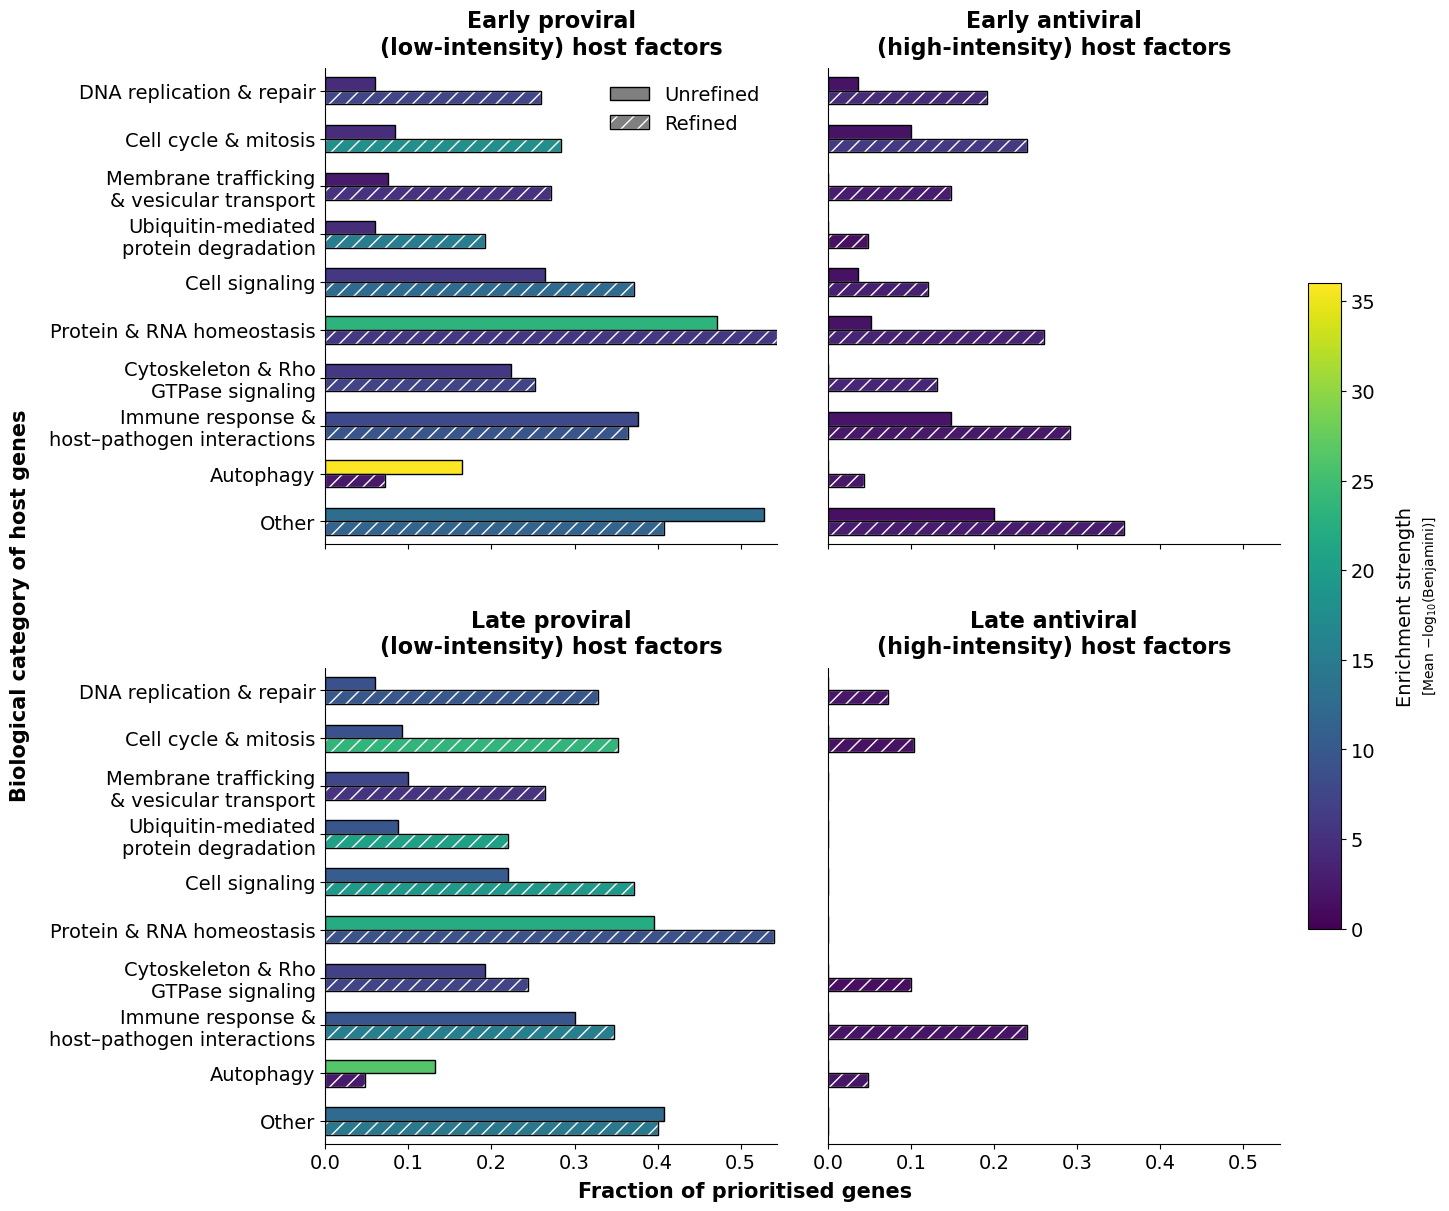

In [54]:
# Generate the figure for the Supplementary Information displaying all
# four intensity regimes

# Generate the figure for the main manuscript displaying
# early and late low- and high-intensity host factors.
#
# Layout:
#   Top-left:     Early proviral (low-intensity)
#   Top-right:    Early antiviral (high-intensity)
#   Bottom-left:  Late proviral (low-intensity)
#   Bottom-right: Late antiviral (high-intensity)
#
# All four panels use:
#   - the same category ordering
#   - the same x-axis scale
#   - the same color normalization
#
# ============================================================
# Select early- and late-intensity data
# ============================================================

early_low_df = comparison_average_long_df[
    comparison_average_long_df["ORA"].isin(
        ["early_low_unrefined", "early_low_refined"]
    )
].copy()

early_high_df = comparison_average_long_df[
    comparison_average_long_df["ORA"].isin(
        ["early_high_unrefined", "early_high_refined"]
    )
].copy()

late_low_df = comparison_average_long_df[
    comparison_average_long_df["ORA"].isin(
        ["late_low_unrefined", "late_low_refined"]
    )
].copy()

late_high_df = comparison_average_long_df[
    comparison_average_long_df["ORA"].isin(
        ["late_high_unrefined", "late_high_refined"]
    )
].copy()


# ============================================================
# Sort categories by the difference in early-low intensities
#
# Difference = early_low_refined - early_low_unrefined
#
# Largest positive difference appears at the top.
# ============================================================

early_unrefined_sort = (
    early_low_df[
        early_low_df["ORA"] == "early_low_unrefined"
    ][["category", "genes_fraction"]]
    .rename(columns={"genes_fraction": "early_unrefined"})
)

early_refined_sort = (
    early_low_df[
        early_low_df["ORA"] == "early_low_refined"
    ][["category", "genes_fraction"]]
    .rename(columns={"genes_fraction": "early_refined"})
)

sort_order_df = (
    early_unrefined_sort
    .merge(
        early_refined_sort,
        on="category",
        how="inner"
    )
)

sort_order_df["early_difference"] = (
    sort_order_df["early_refined"]
    - sort_order_df["early_unrefined"]
)

# Sort ascending because barh() places the first
# category at the bottom of the y-axis.
# Consequently, the largest difference appears at the top.
sort_order_df = sort_order_df.sort_values(
    "early_difference",
    ascending=True
)

category_sort_order = sort_order_df["category"].tolist()

group_spacing = 1.4
y_positions = np.arange(len(category_sort_order)) * group_spacing
bar_height = 0.4


# ============================================================
# Reindex data according to common category order
# ============================================================

early_unrefined = (
    early_low_df[
        early_low_df["ORA"] == "early_low_unrefined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)

early_refined = (
    early_low_df[
        early_low_df["ORA"] == "early_low_refined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)

early_high_unrefined = (
    early_high_df[
        early_high_df["ORA"] == "early_high_unrefined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)

early_high_refined = (
    early_high_df[
        early_high_df["ORA"] == "early_high_refined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)

late_unrefined = (
    late_low_df[
        late_low_df["ORA"] == "late_low_unrefined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)

late_refined = (
    late_low_df[
        late_low_df["ORA"] == "late_low_refined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)

late_high_unrefined = (
    late_high_df[
        late_high_df["ORA"] == "late_high_unrefined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)

late_high_refined = (
    late_high_df[
        late_high_df["ORA"] == "late_high_refined"
    ]
    .set_index("category")
    .reindex(category_sort_order)
)


# ============================================================
# Color map
#
# IMPORTANT:
# Normalization is performed across ALL FOUR panels so that
# the colors have the same quantitative meaning throughout
# the entire figure.
# ============================================================

cmap = plt.get_cmap("viridis")

all_intensity_df = pd.concat(
    [
        early_low_df,
        early_high_df,
        late_low_df,
        late_high_df
    ]
)

norm = plt.Normalize(
    vmin=all_intensity_df[
        "average_minus_log10(Benjamini)"
    ].min(),
    vmax=all_intensity_df[
        "average_minus_log10(Benjamini)"
    ].max()
)


# ============================================================
# Create figure and four Axes
#
# 2 x 2 square arrangement:
#
#   ax1 | ax2
#   ----+----
#   ax3 | ax4
#
# Early plots are in the upper row.
# Late plots are in the lower row.
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 12),
    sharex=True,
    sharey=True,
    gridspec_kw={
        "wspace": 0.05,
        "hspace": 0.10
    },
    constrained_layout=True
)

ax1, ax2 = axes[0]
ax3, ax4 = axes[1]


# ============================================================
# Helper function for plotting one panel
# ============================================================

def plot_comparison(ax, unrefined, refined):
    """
    Plot unrefined and refined horizontal bars on one Axes.
    """

    # --------------------------------------------------------
    # Unrefined
    # --------------------------------------------------------

    ax.barh(
        y_positions + bar_height / 2,
        unrefined["genes_fraction"],
        height=bar_height,
        color=cmap(
            norm(
                unrefined[
                    "average_minus_log10(Benjamini)"
                ]
            )
        ),
        edgecolor="black"
    )

    # --------------------------------------------------------
    # Refined
    #
    # White hatch + white edge gives white hatch lines.
    # --------------------------------------------------------

    ax.barh(
        y_positions - bar_height / 2,
        refined["genes_fraction"],
        height=bar_height,
        color=cmap(
            norm(
                refined[
                    "average_minus_log10(Benjamini)"
                ]
            )
        ),
        edgecolor="white",
        hatch="//"
    )

    # --------------------------------------------------------
    # Overlay transparent bars to restore black outline
    # --------------------------------------------------------

    ax.barh(
        y_positions - bar_height / 2,
        refined["genes_fraction"],
        height=bar_height,
        facecolor="none",
        edgecolor="black"
    )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------

    ax.margins(y=0.02, x=0)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        axis="both",
        labelsize=14
    )


# ============================================================
# Plot the four panels
# ============================================================

# ------------------------------------------------------------
# Top row: Early
# ------------------------------------------------------------

# Panel 1: Early low-intensity proviral host factors
plot_comparison(
    ax1,
    early_unrefined,
    early_refined
)

# Panel 2: Early high-intensity antiviral host factors
plot_comparison(
    ax2,
    early_high_unrefined,
    early_high_refined
)


# ------------------------------------------------------------
# Bottom row: Late
# ------------------------------------------------------------

# Panel 3: Late low-intensity proviral host factors
plot_comparison(
    ax3,
    late_unrefined,
    late_refined
)

# Panel 4: Late high-intensity antiviral host factors
plot_comparison(
    ax4,
    late_high_unrefined,
    late_high_refined
)


# ============================================================
# Axis labels and category labels
# ============================================================

def wrap_to_two_lines(text, width=30):
    words = text.split()

    # Nothing to do for short labels
    if len(text) <= width:
        return text

    # Find the split that gives the most balanced two lines
    best_split = None
    best_difference = float("inf")

    for i in range(1, len(words)):
        line1 = " ".join(words[:i])
        line2 = " ".join(words[i:])

        # Skip splits where either line is excessively long
        if len(line1) > width or len(line2) > width:
            continue

        difference = abs(len(line1) - len(line2))

        if difference < best_difference:
            best_difference = difference
            best_split = (line1, line2)

    # If no split satisfies the width constraint, split at
    # the most balanced word boundary anyway.
    if best_split is None:
        differences = []

        for i in range(1, len(words)):
            line1 = " ".join(words[:i])
            line2 = " ".join(words[i:])
            differences.append(
                (abs(len(line1) - len(line2)), line1, line2)
            )

        _, line1, line2 = min(differences)
        best_split = (line1, line2)

    return "\n".join(best_split)


wrapped_labels = [
    wrap_to_two_lines(lbl, width=30)
    for lbl in category_sort_order
]


# ============================================================
# Y-axis labels
# ============================================================

# Left column gets the category labels
ax1.set_yticks(y_positions)
ax1.set_yticklabels(wrapped_labels)

ax3.set_yticks(y_positions)
ax3.set_yticklabels(wrapped_labels)

fig.supylabel(
    "Biological category of host genes",
    fontweight="bold",
    fontsize=15,
    x=-0.025
)


# ============================================================
# Hide duplicate y-axis labels/ticks on right panels
# ============================================================

for ax in [ax2, ax4]:
    ax.tick_params(
        axis="y",
        left=False,
        labelleft=False
    )


# ============================================================
# Joint x-axis label
# ============================================================

fig.supxlabel(
    "Fraction of prioritised genes",
    fontweight="bold",
    fontsize=15
)


# ============================================================
# Panel titles
# ============================================================

ax1.set_title(
    "Early proviral\n(low-intensity) host factors",
    fontsize=16,
    fontweight="bold",
    pad=10
)

ax2.set_title(
    "Early antiviral\n(high-intensity) host factors",
    fontsize=16,
    fontweight="bold",
    pad=10
)

ax3.set_title(
    "Late proviral\n(low-intensity) host factors",
    fontsize=16,
    fontweight="bold",
    pad=10
)

ax4.set_title(
    "Late antiviral\n(high-intensity) host factors",
    fontsize=16,
    fontweight="bold",
    pad=10
)


# ============================================================
# Colorbar
#
# Let constrained_layout manage the colorbar position.
# shrink controls its height; pad controls its distance
# from the plot axes.
# ============================================================

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes.ravel().tolist(),
    shrink=0.60,
    pad=0.03
)

cbar.ax.tick_params(
    labelsize=14
)

cbar.ax.text(
    3.3, 0.5,
    "Enrichment strength",
    fontsize=14,
    rotation=90,
    rotation_mode="anchor",
    ha="center",
    va="bottom",
    transform=cbar.ax.transAxes,
)

cbar.ax.text(
    3.5, 0.5,
    r"[Mean $-\log_{10}$(Benjamini)]",
    fontsize=10,
    rotation=90,
    rotation_mode="anchor",
    ha="center",
    va="top",
    transform=cbar.ax.transAxes,
)


# ============================================================
# Custom legend handler for refined bars
# ============================================================

class OverlayPatchHandler(HandlerBase):
    """
    Draw multiple patches overlaid in the same legend key.
    """

    def __init__(self, patches, **kwargs):
        self._patches = patches
        super().__init__(**kwargs)

    def create_artists(
        self,
        legend,
        orig_handle,
        xdescent,
        ydescent,
        width,
        height,
        fontsize,
        trans
    ):
        artists = []

        for p in self._patches:
            rect = mpatches.Rectangle(
                (-xdescent, -ydescent),
                width,
                height,
                facecolor=p.get_facecolor(),
                edgecolor=p.get_edgecolor(),
                hatch=p.get_hatch(),
                linewidth=1.0,
                transform=trans
            )
            artists.append(rect)

        return artists


# ============================================================
# Legend
#
# Place the legend only once, in the upper-left panel.
# ============================================================

refined_hatch_patch = mpatches.Patch(
    facecolor="gray",
    edgecolor="white",
    hatch="//"
)

refined_border_patch = mpatches.Patch(
    facecolor="none",
    edgecolor="black"
)

refined_placeholder = mpatches.Patch(
    label="Refined"
)

legend_handles = [
    mpatches.Patch(
        facecolor="gray",
        edgecolor="black",
        label="Unrefined"
    ),
    refined_placeholder
]

ax1.legend(
    handles=legend_handles,
    handler_map={
        refined_placeholder:
            OverlayPatchHandler(
                [
                    refined_hatch_patch,
                    refined_border_patch
                ]
            )
    },
    frameon=False,
    fontsize=14,
    loc="upper right"
)


# ============================================================
# X-axis limits
#
# Use one common limit across all four panels.
# ============================================================

max_fraction = max(
    early_low_df["genes_fraction"].max(),
    early_high_df["genes_fraction"].max(),
    late_low_df["genes_fraction"].max(),
    late_high_df["genes_fraction"].max()
)

for ax in axes.ravel():
    ax.set_xlim(0, max_fraction)


# ============================================================
# Final layout
# ============================================================

plt.show()


# ============================================================
# Save figure
# ============================================================

fig.savefig(
    os.path.join(
        ora_comparison_plots_dir,
        "comparison_early_and_late_low_and_high.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    os.path.join(
        ora_comparison_plots_dir,
        "comparison_early_and_late_low_and_high.svg"
    ),
    bbox_inches="tight"
)